# GoldCast — Next-Day Gold Price Forecasting

A concise walkthrough of the pipeline in `src/`: load and audit the raw
data, engineer leakage-free features, split chronologically into
train/validation/test, fit a Naive baseline, ARIMA, Random Forest, and
XGBoost, and evaluate all four on the held-out test set only.

Every number below comes from actually running this notebook — see the
project `README.md` for the full write-up and discussion.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import matplotlib.pyplot as plt

from preprocessing import load_raw_data, audit_dataset, clean_dataset
from features import build_features
from models import (
    naive_forecast, fit_predict_arima,
    build_random_forest, build_xgboost,
    rf_param_search_space, xgb_param_search_space,
    tune_with_timeseries_cv,
)
from evaluation import compute_metrics, build_results_table

pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

## 1. Load & audit the raw data

In [2]:
raw = load_raw_data('../data/GoldPrice.csv')
audit = audit_dataset(raw)
for k, v in audit.items():
    print(f'{k}: {v}')

n_rows: 2531
n_columns: 6
columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Chg%']
missing_values_per_column: {'Date': 0, 'Price': 0, 'Open': 0, 'High': 0, 'Low': 0, 'Chg%': 0}
duplicate_rows: 0
duplicate_dates: 0
min_date: 2011-01-03
max_date: 2020-09-11
sorted_ascending_as_loaded: False
rows_with_nonpositive_price: 0


## 2. Clean (every step logged, nothing silently dropped)

In [3]:
cleaned, clean_log = clean_dataset(raw)
for k, v in clean_log.items():
    print(f'{k}: {v}')
cleaned.head()

rows_before: 2531
duplicate_dates_removed: 0
duplicate_rows_removed: 0
missing_values_found: 0
nonpositive_price_rows_removed: 0
rows_after: 2531
total_rows_removed: 0


,Date,Price,Open,High,Low,Chg%
0,2011-01-03,"1,422.600","1,415.600","1,423.900","1,413.700",0.001
1,2011-01-04,"1,378.500","1,409.600","1,410.900","1,375.800",-0.031
2,2011-01-05,"1,373.400","1,383.400","1,384.000","1,364.200",-0.004
3,2011-01-06,"1,371.400","1,374.800","1,376.500","1,368.900",-0.002
4,2011-01-07,"1,368.500","1,372.700","1,377.200","1,355.500",-0.002


## 3. Exploratory data analysis

### 3.1 Price history

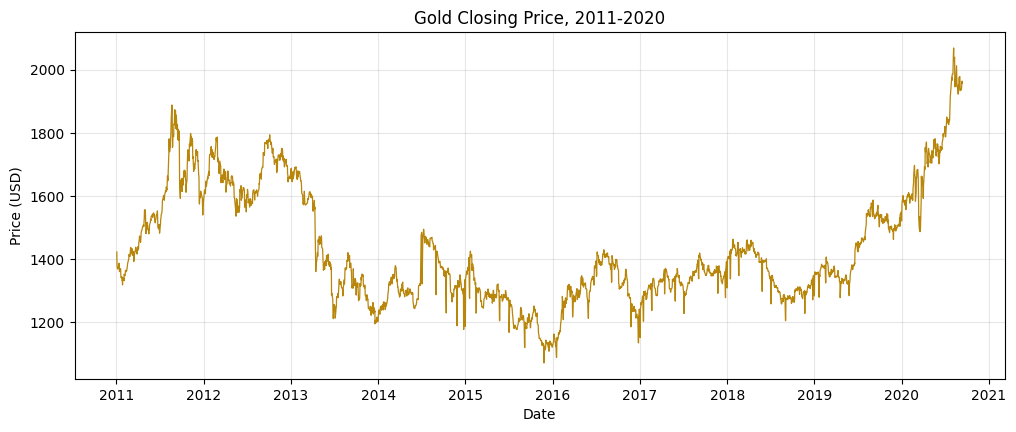

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(cleaned['Date'], cleaned['Price'], linewidth=0.9, color='#b8860b')
ax.set_title('Gold Closing Price, 2011-2020')
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD)')
ax.grid(alpha=0.3)
plt.show()

### 3.2 Daily returns and rolling volatility

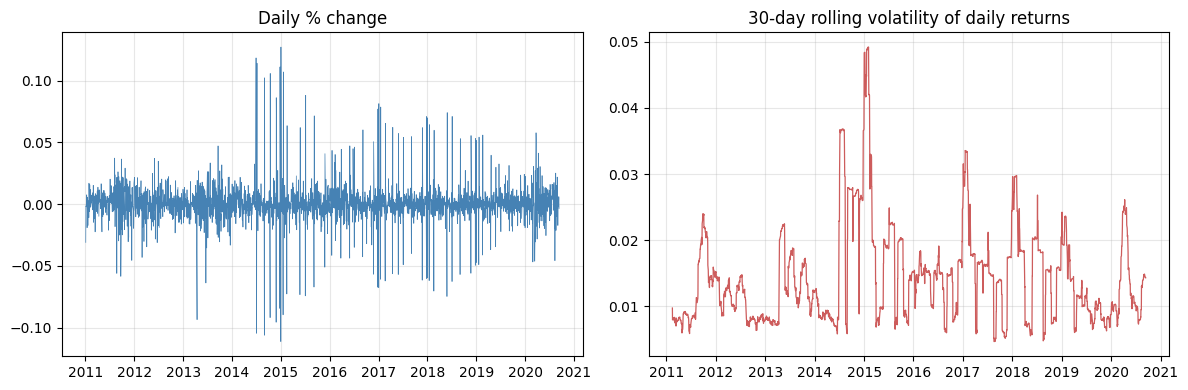

Mean absolute daily return: 0.891% of price


In [5]:
daily_return = cleaned['Price'].pct_change().dropna()
rolling_vol = cleaned['Price'].pct_change().rolling(30).std()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cleaned['Date'].iloc[1:], daily_return, linewidth=0.5, color='steelblue')
axes[0].set_title('Daily % change'); axes[0].grid(alpha=0.3)
axes[1].plot(cleaned['Date'], rolling_vol, linewidth=0.9, color='indianred')
axes[1].set_title('30-day rolling volatility of daily returns'); axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Mean absolute daily return: {daily_return.abs().mean() * 100:.3f}% of price")

## 4. Feature engineering (leakage-free)

Target: **next trading day's Price**. Every feature at row *t* is built
from day *t* or earlier — same-day Open/High/Low/Chg% are excluded, since
they correlate at ~0.98-0.99 with same-day Price and would let a model do
same-day arithmetic instead of forecasting. Four feature families: lag,
rolling statistics, returns, and momentum.

In [6]:
feat, feat_log = build_features(cleaned)
for k, v in feat_log.items():
    if k != 'final_feature_columns':
        print(f'{k}: {v}')
print(f"Feature columns ({len(feat_log['final_feature_columns'])}): {feat_log['final_feature_columns']}")
feat.head()

rows_before_feature_engineering: 2531
rows_dropped_no_target: 1
rows_dropped_insufficient_history: 29
rows_after_feature_engineering: 2501
Feature columns (19): ['price', 'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_5', 'price_lag_7', 'price_lag_14', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30', 'rolling_std_30', 'return_1d', 'return_3d', 'return_7d', 'return_14d', 'momentum_5', 'momentum_10']


,Date,price,price_lag_1,price_lag_2,price_lag_3,price_lag_5,price_lag_7,price_lag_14,rolling_mean_7,rolling_std_7,...,rolling_std_14,rolling_mean_30,rolling_std_30,return_1d,return_3d,return_7d,return_14d,momentum_5,momentum_10,target_next_day_price
0,2011-02-14,"1,364.600","1,359.900","1,361.900","1,364.800","1,347.600","1,352.300","1,332.300","1,358.643",7.496,...,14.772,"1,358.917",21.681,0.003,-0.000,0.009,0.024,17.000,30.800,"1,373.600"
1,2011-02-15,"1,373.600","1,364.600","1,359.900","1,361.900","1,363.400","1,348.300","1,333.000","1,362.257",7.772,...,15.739,"1,357.283",18.300,0.007,0.009,0.019,0.030,10.200,34.000,"1,374.700"
2,2011-02-16,"1,374.700","1,373.600","1,364.600","1,359.900","1,364.800","1,347.600","1,318.400","1,366.129",5.738,...,14.148,"1,357.157",18.161,0.001,0.011,0.020,0.043,9.900,43.200,"1,384.700"
3,2011-02-17,"1,384.700","1,374.700","1,373.600","1,364.600","1,361.900","1,363.400","1,340.700","1,369.171",8.852,...,15.750,"1,357.533",18.621,0.007,0.015,0.016,0.033,22.800,32.400,"1,388.200"
4,2011-02-18,"1,388.200","1,384.700","1,374.700","1,373.600","1,359.900","1,364.800","1,333.800","1,372.514",11.067,...,16.238,"1,358.093",19.293,0.003,0.011,0.017,0.041,28.300,39.900,"1,400.500"


## 5. Chronological train / validation / test split

In [7]:
TRAIN_FRACTION, VAL_FRACTION = 0.70, 0.15
n = len(feat)
train_end = int(n * TRAIN_FRACTION)
val_end = int(n * (TRAIN_FRACTION + VAL_FRACTION))

train_df = feat.iloc[:train_end].reset_index(drop=True)
val_df = feat.iloc[train_end:val_end].reset_index(drop=True)
test_df = feat.iloc[val_end:].reset_index(drop=True)
trainval_df = feat.iloc[:val_end].reset_index(drop=True)

feature_cols = feat_log['final_feature_columns']
X_train, y_train = train_df[feature_cols], train_df['target_next_day_price']
X_trainval, y_trainval = trainval_df[feature_cols], trainval_df['target_next_day_price']
X_test, y_test = test_df[feature_cols], test_df['target_next_day_price']

assert train_df['Date'].max() < val_df['Date'].min() < test_df['Date'].max()
print(f"Train: {len(train_df)} rows ({train_df['Date'].min().date()} -> {train_df['Date'].max().date()})")
print(f"Val:   {len(val_df)} rows ({val_df['Date'].min().date()} -> {val_df['Date'].max().date()})")
print(f"Test:  {len(test_df)} rows ({test_df['Date'].min().date()} -> {test_df['Date'].max().date()})")

Train: 1750 rows (2011-02-14 -> 2017-11-09)
Val:   375 rows (2017-11-10 -> 2019-04-11)
Test:  376 rows (2019-04-12 -> 2020-09-10)


## 6. Models: Naive, ARIMA, Random Forest, XGBoost

Random Forest and XGBoost are tuned with `TimeSeriesSplit` cross-validation
on the **train** split only (lightweight `RandomizedSearchCV`), then
refit on train+validation with the selected hyperparameters. ARIMA is fit
once on train+validation and walked forward one step at a time through the
test set. None of this touches the test labels.

In [8]:
results = {}
predictions = pd.DataFrame({'Date': test_df['Date'], 'Actual': y_test.reset_index(drop=True)})

# Naive: tomorrow's price = today's price
naive_preds = naive_forecast(test_df['price'])
results['Naive'] = compute_metrics(y_test, naive_preds)
predictions['Naive'] = naive_preds

# ARIMA(5,1,0), walk-forward
arima_preds = fit_predict_arima(trainval_df['price'].to_numpy(), test_df['price'].to_numpy())
results['ARIMA'] = compute_metrics(y_test, arima_preds)
predictions['ARIMA'] = arima_preds
print('Naive and ARIMA done.')

Naive and ARIMA done.


In [9]:
# Random Forest: TimeSeriesSplit tuning on train, refit on train+val
_, rf_best_params, rf_cv_rmse = tune_with_timeseries_cv(
    build_random_forest(), rf_param_search_space(), X_train, y_train)
rf_final = build_random_forest(**rf_best_params)
rf_final.fit(X_trainval, y_trainval)
rf_preds = rf_final.predict(X_test)
results['Random Forest'] = compute_metrics(y_test, rf_preds)
predictions['RandomForest'] = rf_preds
print(f'Random Forest best params: {rf_best_params} (CV RMSE {rf_cv_rmse:.3f})')

Random Forest best params: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 1.0, 'max_depth': 8} (CV RMSE 40.999)


In [10]:
# XGBoost: TimeSeriesSplit tuning on train, refit on train+val
_, xgb_best_params, xgb_cv_rmse = tune_with_timeseries_cv(
    build_xgboost(), xgb_param_search_space(), X_train, y_train)
xgb_final = build_xgboost(**xgb_best_params)
xgb_final.fit(X_trainval, y_trainval)
xgb_preds = xgb_final.predict(X_test)
results['XGBoost'] = compute_metrics(y_test, xgb_preds)
predictions['XGBoost'] = xgb_preds
print(f'XGBoost best params: {xgb_best_params} (CV RMSE {xgb_cv_rmse:.3f})')

XGBoost best params: {'subsample': 0.85, 'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.1} (CV RMSE 41.602)


## 7. Results — test set only

In [11]:
results_table = build_results_table(results)
results_table

,MAE,RMSE,R2
Naive,13.433,19.876,0.988
ARIMA,19.673,28.221,0.976
XGBoost,28.150,50.690,0.921
Random Forest,31.720,55.859,0.905


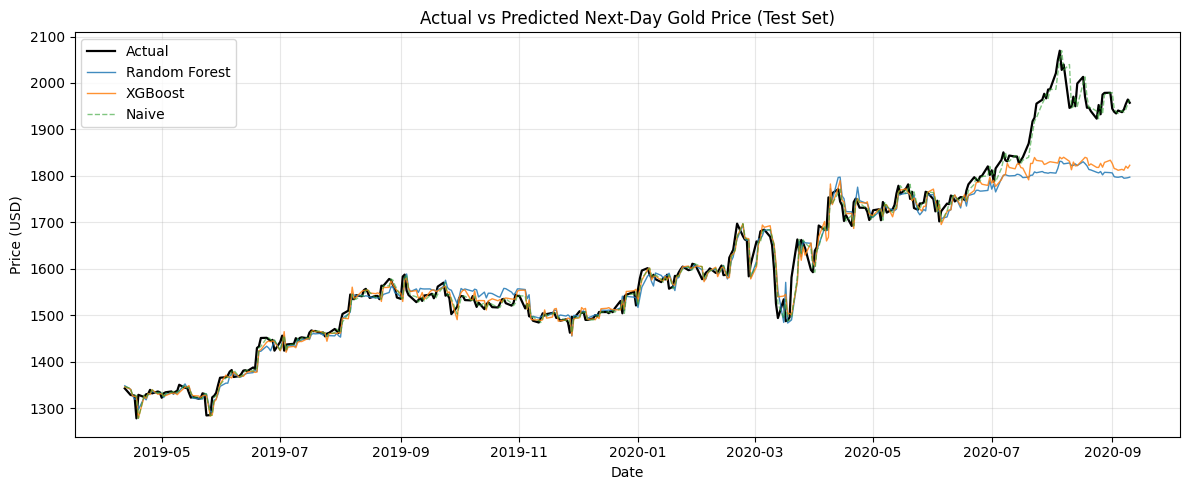

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_df['Date'], y_test.values, label='Actual', color='black', linewidth=1.6)
ax.plot(test_df['Date'], rf_preds, label='Random Forest', linewidth=1.0, alpha=0.85)
ax.plot(test_df['Date'], xgb_preds, label='XGBoost', linewidth=1.0, alpha=0.85)
ax.plot(test_df['Date'], naive_preds, label='Naive', linewidth=1.0, alpha=0.6, linestyle='--')
ax.set_title('Actual vs Predicted Next-Day Gold Price (Test Set)')
ax.set_xlabel('Date'); ax.set_ylabel('Price (USD)')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Feature importance

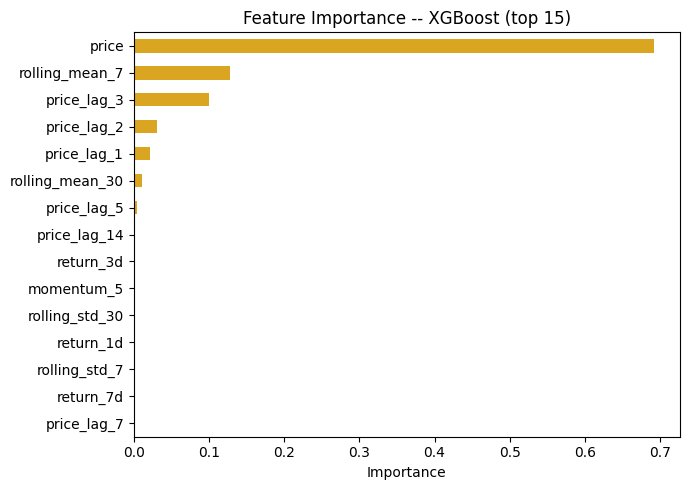

In [13]:
best_tree = 'Random Forest' if results['Random Forest']['RMSE'] <= results['XGBoost']['RMSE'] else 'XGBoost'
best_tree_model = rf_final if best_tree == 'Random Forest' else xgb_final
importances = pd.Series(best_tree_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
importances.head(15).sort_values().plot(kind='barh', ax=ax, color='goldenrod')
ax.set_title(f'Feature Importance -- {best_tree} (top 15)')
ax.set_xlabel('Importance')
fig.tight_layout()
plt.show()

## 9. Conclusion

- Gold's daily price series is close to a random walk (mean absolute daily
  move ~0.7-0.8% of price, see section 3.2), so "today's price" is already
  a very strong predictor of "tomorrow's price" — the **Naive** baseline is
  genuinely hard to beat.
- On this chronological split, the test period (2019-04 to 2020-09) includes
  the sharp 2020 gold rally to all-time highs. **Random Forest** and
  **XGBoost** are tree ensembles: their predictions are bounded by the price
  range seen during training, so they systematically undershoot once price
  moves into new territory — visible in the plot above. **ARIMA**, fit on
  differenced price and walked forward one step at a time, tracks the trend
  more closely but still trails Naive.
- This is reported honestly rather than tuned away: see the full
  `README.md` for the complete discussion and the exact numbers in
  `results/model_comparison.csv`.